In [1]:
import pandas as pd

In [2]:
df = pd.read_csv("/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/results/allocation/norman_results_all.csv")

In [3]:
df.head()


,Unnamed: 0,subgroup,condition,encoded_ood_r_squared,encoded_ood_sinkhorn_div_1,encoded_ood_sinkhorn_div_10,encoded_ood_sinkhorn_div_100,encoded_ood_e_distance,encoded_ood_mmd,decoded_ood_r_squared,...,deg_ood_sinkhorn_div_1,deg_ood_sinkhorn_div_10,deg_ood_sinkhorn_div_100,deg_ood_e_distance,deg_ood_mmd,seed,model,decoded_ood_sinkhorn_div_1,decoded_ood_sinkhorn_div_10,decoded_ood_sinkhorn_div_100
0,0,double_seen_1,AHR+KLF1,-0.235969,26.363504,20.453796,13.004532,23.576266,0.088512,0.965454,...,49.004730,23.053215,9.580486,18.465538,0.055382,1,biolord,NaN,NaN,NaN
1,1,single,ARID1A+ctrl,-0.870820,32.711014,26.043972,15.835747,26.292580,0.075837,0.957185,...,51.148735,24.314388,9.643890,18.312755,0.052491,1,biolord,NaN,NaN,NaN
2,2,double_seen_1,BCL2L11+BAK1,0.912641,8.554052,2.861893,0.661819,0.830657,0.019190,0.984661,...,40.841179,14.373302,0.673000,0.470072,0.452304,1,biolord,NaN,NaN,NaN
3,3,double_seen_1,BCL2L11+TGFBR2,0.863316,9.772830,4.568264,0.941708,1.115361,0.019349,0.985263,...,38.525169,14.326378,1.011749,1.303958,0.060637,1,biolord,NaN,NaN,NaN
4,4,single,BCL2L11+ctrl,0.888504,9.687116,4.609301,0.755690,0.728787,0.016104,0.986481,...,39.652954,13.896275,0.832378,0.833630,0.280454,1,biolord,NaN,NaN,NaN


In [4]:
dfs = []
for split in range(5):
    df_tmp = pd.read_csv(f"/lustre/groups/ml01/workspace/ot_perturbation/data/norman_2/cellflow/norman_results_all_{split}_new.csv")
    df_tmp["seed"] = split+1
    dfs.append(df_tmp)

In [5]:
df_cf = pd.concat(dfs)

In [6]:
df_cf.head()

,Unnamed: 0,encoded_ood_r_squared,encoded_ood_e_distance,encoded_ood_mmd,condition,decoded_ood_r_squared,decoded_ood_e_distance,decoded_ood_mmd,deg_ood_r_squared,deg_ood_e_distance,deg_ood_mmd,subgroup,model,seed
0,AHR+KLF1,-3.196409,80.047180,0.101908,AHR+KLF1,0.943107,98.755310,0.072455,0.749556,27.832890,0.092647,double_seen_1,cellflow,1
1,ARID1A+ctrl,-0.047760,14.725246,0.031228,ARID1A+ctrl,0.976003,36.686913,0.099168,0.919292,12.933991,0.078776,single,cellflow,1
2,BCL2L11+BAK1,-0.167336,11.099590,0.030859,BCL2L11+BAK1,0.990821,15.275223,0.066400,0.528541,0.316262,0.115870,double_seen_1,cellflow,1
3,BCL2L11+TGFBR2,-0.384189,11.295197,0.028339,BCL2L11+TGFBR2,0.991123,14.532181,0.064382,0.890575,6.525801,0.058881,double_seen_1,cellflow,1
4,BCL2L11+ctrl,-0.616587,10.566673,0.027335,BCL2L11+ctrl,0.991841,13.408546,0.064015,0.953577,0.918859,0.133346,single,cellflow,1


In [7]:
df_cf["model"] = "cellflow_new"

In [8]:
df_all = pd.concat((df, df_cf))
df = df_all

In [11]:
df.to_csv("/home/icb/dominik.klein/tmp/norman_new.csv")

In [47]:
len(df), len(df_all)

(3430, 3430)

In [49]:
df_single = df[df["subgroup"]=="single"]

In [50]:
df_single.groupby("model")[["decoded_ood_r_squared", "encoded_ood_e_distance"]].mean()

,decoded_ood_r_squared,encoded_ood_e_distance
model,,
biolord,0.969143,20.004289
cellflow,0.981737,19.272632
cellflow_new,0.982074,19.331403
gears,0.979529,17.913590
identity,0.976298,28.358846
scgpt,0.978895,21.666171


In [51]:
df_single.groupby(["model", "seed"])[["decoded_ood_r_squared", "encoded_ood_e_distance"]].mean()

decoded_ood_r_squared  encoded_ood_e_distance
model        seed                                               
biolord      1                  0.965597               22.189139
             2                  0.967390               25.762848
             3                  0.974843               11.852105
             4                  0.972546               13.520697
             5                  0.965823               25.841740
cellflow     1                  0.976645               25.245347
             2                  0.979733               23.347277
             3                  0.985485               13.257366
             4                  0.984044               14.651481
             5                  0.982763               19.666067
cellflow_new 1                  0.980908               19.249610
             2                  0.979021               25.275988
             3                  0.985404               13.439789
             4                  0.985467               12.877496
             5                  0.979894               25.031302
gears        1                  0.978662               14.485275
             2                  0.978654               20.698808
             3                  0.982817               13.316143
             4                  0.982473               12.368472
             5                  0.975518               27.574745
identity     1                  0.976417               25.554726
             2                  0.970313               39.770383
             3                  0.981673               18.412072
             4                  0.981706               18.284895
             5                  0.972021               38.348713
scgpt        1                  0.981459               15.059984
             2                  0.972559               32.960296
             3                  0.983129               14.532887
             4                  0.983502               12.274633
             5                  0.974481               32.093471

In [67]:
df_single_1 = df_single[df_single["seed"]==4]

In [68]:
len(df_single_1)

222

<Axes: xlabel='model', ylabel='encoded_ood_e_distance'>

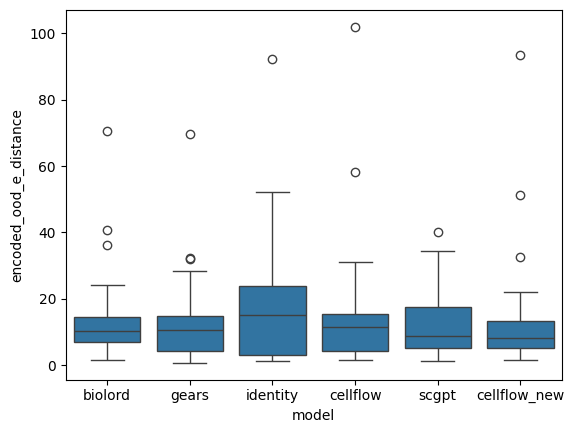

In [69]:
import seaborn as sns
sns.boxplot(df_single_1, y="encoded_ood_e_distance", x="model")

In [32]:
df_d0 = df[df["subgroup"]=="double_seen_0"]

In [33]:
df_d0.groupby("model")[["decoded_ood_r_squared", "encoded_ood_e_distance"]].mean()
# 0.980, 32.3
# 0.96, 42.0 


,decoded_ood_r_squared,encoded_ood_e_distance
model,,
biolord,0.937300,41.544683
cellflow,0.970438,31.540007
cellflow_new,0.971840,29.108704
gears,0.959496,32.278726
identity,0.950372,64.222289
scgpt,0.963715,41.949575


In [34]:
df_d1 = df[df["subgroup"]=="double_seen_1"]

In [35]:
df_d1.groupby("model")[["decoded_ood_r_squared", "encoded_ood_e_distance"]].mean()
# 0.985, 25.9
# 0.970, 33.4

,decoded_ood_r_squared,encoded_ood_e_distance
model,,
biolord,0.964025,25.625659
cellflow,0.977222,23.725745
cellflow_new,0.978158,22.182514
gears,0.966460,21.986434
identity,0.951428,62.657669
scgpt,0.970232,31.844922


In [36]:
df_d2 = df[df["subgroup"]=="double_seen_2"]

In [37]:
df_d2.groupby("model")[["decoded_ood_r_squared", "encoded_ood_e_distance"]].mean()
# 0.996, 6.88
# 0.974, 29.8

,decoded_ood_r_squared,encoded_ood_e_distance
model,,
additive,0.989467,8.648598
biolord,0.989400,8.382792
cellflow,0.988620,7.831059
cellflow_new,0.990358,5.550758
gears,0.973730,10.256235
identity,0.952080,61.433762
scgpt,0.979765,17.285718


In [ ]:
df_d3

In [13]:
df.head()

,Unnamed: 0,subgroup,condition,encoded_ood_r_squared,encoded_ood_sinkhorn_div_1,encoded_ood_sinkhorn_div_10,encoded_ood_sinkhorn_div_100,encoded_ood_e_distance,encoded_ood_mmd,decoded_ood_r_squared,...,deg_ood_sinkhorn_div_1,deg_ood_sinkhorn_div_10,deg_ood_sinkhorn_div_100,deg_ood_e_distance,deg_ood_mmd,seed,model,decoded_ood_sinkhorn_div_1,decoded_ood_sinkhorn_div_10,decoded_ood_sinkhorn_div_100
0,0,double_seen_1,AHR+KLF1,-0.235969,26.363504,20.453796,13.004532,23.576266,0.088512,0.965454,...,49.004730,23.053215,9.580486,18.465538,0.055382,1,biolord,NaN,NaN,NaN
1,1,single,ARID1A+ctrl,-0.870820,32.711014,26.043972,15.835747,26.292580,0.075837,0.957185,...,51.148735,24.314388,9.643890,18.312755,0.052491,1,biolord,NaN,NaN,NaN
2,2,double_seen_1,BCL2L11+BAK1,0.912641,8.554052,2.861893,0.661819,0.830657,0.019190,0.984661,...,40.841179,14.373302,0.673000,0.470072,0.452304,1,biolord,NaN,NaN,NaN
3,3,double_seen_1,BCL2L11+TGFBR2,0.863316,9.772830,4.568264,0.941708,1.115361,0.019349,0.985263,...,38.525169,14.326378,1.011749,1.303958,0.060637,1,biolord,NaN,NaN,NaN
4,4,single,BCL2L11+ctrl,0.888504,9.687116,4.609301,0.755690,0.728787,0.016104,0.986481,...,39.652954,13.896275,0.832378,0.833630,0.280454,1,biolord,NaN,NaN,NaN


In [14]:
df["seed"].value_counts()

seed
2    600
5    598
4    567
3    554
1    550
Name: count, dtype: int64

In [ ]:
multi_steps=20 # 50
Ema = 1.0 # 0.001
Reg = 0.1 # 0.5 (old / default: 0.0)
cond_output_dropout= 0.8 # old: 0.5
flow_noise = 1.0 # 0.5
time_encodeR_dims = 1024 # [256, 256, 256]
model.time_max_period = 10000 # 0/None
model.hidden_dims=1024 (strong) # [2048, 2048]
time_encoder_dropout=0.0 (strong) # 0.2

In [15]:
df.head()

,Unnamed: 0,subgroup,condition,encoded_ood_r_squared,encoded_ood_sinkhorn_div_1,encoded_ood_sinkhorn_div_10,encoded_ood_sinkhorn_div_100,encoded_ood_e_distance,encoded_ood_mmd,decoded_ood_r_squared,...,deg_ood_sinkhorn_div_1,deg_ood_sinkhorn_div_10,deg_ood_sinkhorn_div_100,deg_ood_e_distance,deg_ood_mmd,seed,model,decoded_ood_sinkhorn_div_1,decoded_ood_sinkhorn_div_10,decoded_ood_sinkhorn_div_100
0,0,double_seen_1,AHR+KLF1,-0.235969,26.363504,20.453796,13.004532,23.576266,0.088512,0.965454,...,49.004730,23.053215,9.580486,18.465538,0.055382,1,biolord,NaN,NaN,NaN
1,1,single,ARID1A+ctrl,-0.870820,32.711014,26.043972,15.835747,26.292580,0.075837,0.957185,...,51.148735,24.314388,9.643890,18.312755,0.052491,1,biolord,NaN,NaN,NaN
2,2,double_seen_1,BCL2L11+BAK1,0.912641,8.554052,2.861893,0.661819,0.830657,0.019190,0.984661,...,40.841179,14.373302,0.673000,0.470072,0.452304,1,biolord,NaN,NaN,NaN
3,3,double_seen_1,BCL2L11+TGFBR2,0.863316,9.772830,4.568264,0.941708,1.115361,0.019349,0.985263,...,38.525169,14.326378,1.011749,1.303958,0.060637,1,biolord,NaN,NaN,NaN
4,4,single,BCL2L11+ctrl,0.888504,9.687116,4.609301,0.755690,0.728787,0.016104,0.986481,...,39.652954,13.896275,0.832378,0.833630,0.280454,1,biolord,NaN,NaN,NaN


In [16]:
df.columns

Index(['Unnamed: 0', 'subgroup', 'condition', 'encoded_ood_r_squared',
       'encoded_ood_sinkhorn_div_1', 'encoded_ood_sinkhorn_div_10',
       'encoded_ood_sinkhorn_div_100', 'encoded_ood_e_distance',
       'encoded_ood_mmd', 'decoded_ood_r_squared', 'decoded_ood_e_distance',
       'decoded_ood_mmd', 'deg_ood_r_squared', 'deg_ood_sinkhorn_div_1',
       'deg_ood_sinkhorn_div_10', 'deg_ood_sinkhorn_div_100',
       'deg_ood_e_distance', 'deg_ood_mmd', 'seed', 'model',
       'decoded_ood_sinkhorn_div_1', 'decoded_ood_sinkhorn_div_10',
       'decoded_ood_sinkhorn_div_100'],
      dtype='object')